# Machine Learning Project Based Learnig Step By Step 

#### 1. Scikit Learn Projects.

## Importing libraries.

In [5]:
import IPython
import sklearn as sk
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

print('Ipython version:',IPython.__version__)
print('sklearn version: ',sk.__version__)
print('pandas version: ',pd.__version__)
print('numpy version: ',np.__version__)
print('matplotlib version:',matplotlib.__version__)


Ipython version: 9.7.0
sklearn version:  1.7.2
pandas version:  2.3.3
numpy version:  2.3.5
matplotlib version: 3.10.6


#### Importing Iris Dataset from Scikit Learn

In [8]:
from sklearn import datasets

iris = datasets.load_iris()
x_iris, y_iris = iris.data,iris.target

print(x_iris.shape,y_iris.shape)
print(x_iris[0],y_iris[0])

(150, 4) (150,)
[5.1 3.5 1.4 0.2] 0


#### Separating the datasets into Train and test sets.

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Get dataset with only the first two attributes
x, y = x_iris[:,:2], y_iris

# Split the dataset into a trainig and a testing set
# Test set will be the 25% taken randomly
x_train,x_test,y_train,y_test = train_test_split(x,y, test_size=0.25, random_state=33)
print(x_train.shape,y_train.shape)

# standardize the features
scaler = StandardScaler().fit(x_train)
x_train = scaler.transform(x_train)
x_test = scaler.transform(x_test)

(112, 2) (112,)


#### Ploting the train data using pyplot

Text(0, 0.5, 'sepal width')

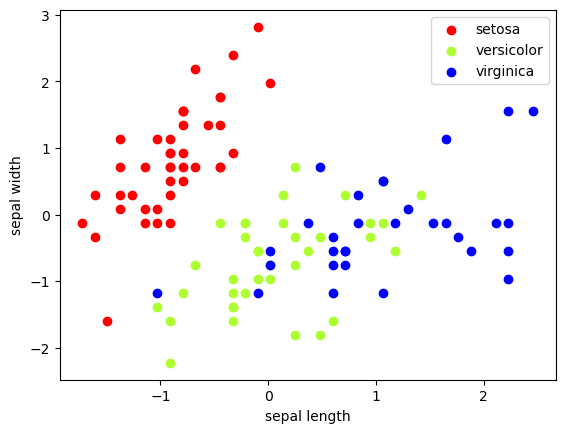

In [24]:
colors = ["red", "greenyellow", "blue"]
for i in range(len(colors)):
    mask = (y_train == i)
    px = x_train[mask,0]
    py = x_train[mask,1]
    plt.scatter(px, py, c=colors[i])

plt.legend(iris.target_names)
plt.xlabel("sepal length")
plt.ylabel("sepal width")

  

#### linear classification Using SGDClassifier from scikit-learn

In [27]:
# create the linear model classifier
from sklearn.linear_model import SGDClassifier
clf = SGDClassifier()

# fit (train) the classifier
clf.fit(x_train, y_train)

# print laerned coefficients
print(clf.coef_)
print(clf.intercept_)


[[-35.66305379  12.87004956]
 [  0.76964947  -3.13383254]
 [  8.79916449   2.67456647]]
[-13.72551442  -2.85306808  -2.51012289]


#### plot the three calculated curves.

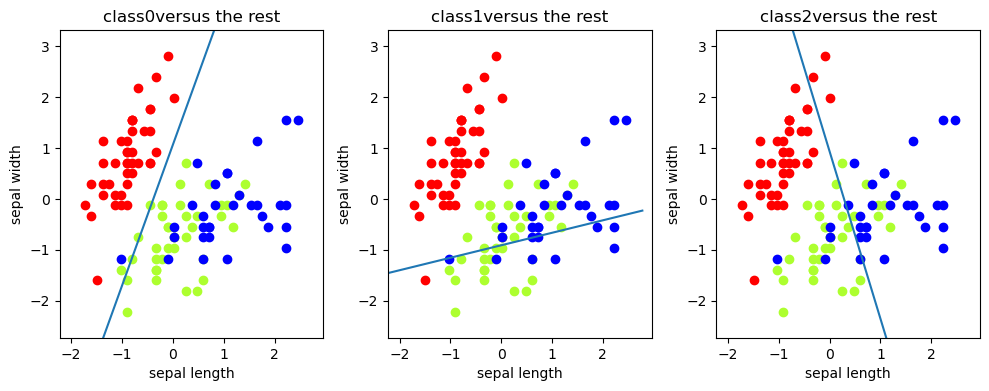

In [31]:
x_min, x_max = x_train[:, 0].min() - 0.5, x_train[:, 0].max() + 0.5
y_min, y_max = x_train[:, 1].min() - 0.5, x_train[:, 1].max() + 0.5
xs = np.arange(x_min, x_max, 0.5)

fig, axes = plt.subplots(1, 3, figsize=(10, 6))
colors = ["red", "greenyellow", "blue"]

for i in range(3):
    axes[i].set_aspect("equal")
    axes[i].set_title("class" + str(i) + "versus the rest")
    axes[i].set_xlabel("sepal length")
    axes[i].set_ylabel("sepal width")
    
    axes[i].set_xlim(x_min, x_max)
    axes[i].set_ylim(y_min, y_max)
    plt.sca(axes[i])
    for j in range(len(colors)):
        mask = (y_train==j)
        px = x_train[mask,0]
        py = x_train[mask,1]
        plt.scatter(px, py, c=colors[j])
    ys = (-clf.intercept_[i]-xs*clf.coef_[i,0])/clf.coef_[i,1]
    plt.plot(xs,ys)

plt.tight_layout()
plt.show()

#### Lets test how can classifier predict

In [35]:
print(clf.predict(scaler.transform([[4.7,3.1]])))

print(clf.decision_function([[4.7,3.1]]))

[0]
[[-141.44471359   -8.95059644   47.13710626]]


#### Test classifier accuracy on training data

In [40]:
from sklearn import metrics
y_train_pred = clf.predict(x_train)
print (metrics.accuracy_score(y_train, y_train_pred))

0.8125


#### Accuracy on Test data

In [42]:
y_pred = clf.predict(x_test)
print (metrics.accuracy_score(y_test, y_pred))

0.6842105263157895


#### Additinoal measures: Precision, Recall and F-score, and show the confusion matrix

In [45]:

print (metrics.classification_report(y_test, y_pred, target_names=iris.target_names))
print (metrics.confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00         8
  versicolor       0.43      0.27      0.33        11
   virginica       0.65      0.79      0.71        19

    accuracy                           0.68        38
   macro avg       0.69      0.69      0.68        38
weighted avg       0.66      0.68      0.66        38

[[ 8  0  0]
 [ 0  3  8]
 [ 0  4 15]]


#### Measure the cross-validation accuracy for each fold:

In [49]:

from sklearn.model_selection import cross_val_score, KFold
from sklearn.pipeline import Pipeline

# create a composite estimator made by a pipeline of the standarization and the linear model
clf = Pipeline([
        ("scaler", StandardScaler()),
        ("linear_model", SGDClassifier())
])

# create a k-fold croos validation iterator of k=5 folds
cv = KFold(n_splits=5, shuffle=True, random_state=33)

# by default the score used is the one returned by score method of the estimator (accuracy)
scores = cross_val_score(clf, x, y, cv=cv)
print (scores)

[0.66666667 0.8        0.76666667 0.86666667 0.86666667]


#### Calculate the mean and standard error of cross-validation accuracy

In [52]:
from scipy.stats import sem

def mean_score(scores):
    """Print the empirical mean score and standard error of the mean."""
    return ("Mean score: {0:.3f} (+/-{1:.3f})").format(
    np.mean(scores), sem(scores))

print (mean_score(scores))

Mean score: 0.793 (+/-0.037)


# END OF MUDULE 1 , Written by Peter Owili